# Notebook 03 — KPI Analysis & Dashboard Design

*Project:* GA4 + GTM Analytics — Google Merchandise Store  
*Analyst:* Philip Ocheri  
*Notebook Purpose:* Build and document the core KPI framework for a DTC e-commerce brand, analyse performance by channel, device, and time period, and prepare data exports for Power BI dashboard.

---

## 1. Load Audited Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/processed/ga_sessions_2017_audited.csv')
df['date'] = pd.to_datetime(df['date'])

print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (213, 14)
Columns: ['date', 'total_sessions', 'total_transactions', 'total_revenue', 'total_visits', 'total_bounces', 'month', 'month_name', 'week', 'session_visit_gap', 'bounce_rate', 'conversion_rate', 'is_revenue_outlier', 'is_zero_conversion']


,date,total_sessions,total_transactions,total_revenue,total_visits,total_bounces,month,month_name,week,session_visit_gap,bounce_rate,conversion_rate,is_revenue_outlier,is_zero_conversion
0,2017-01-01,1364,11,993.01,1364,702,1,Jan,52,0,51.466276,0.806452,False,False
1,2017-01-02,1620,18,1027.60,1620,774,1,Jan,1,0,47.777778,1.111111,False,False
2,2017-01-03,2403,32,4574.74,2403,1087,1,Jan,1,0,45.235123,1.331669,False,False
3,2017-01-04,2390,31,4777.14,2390,1045,1,Jan,1,0,43.723849,1.297071,False,False
4,2017-01-05,2193,41,9097.97,2193,1008,1,Jan,1,0,45.964432,1.869585,False,False


## 2. Core KPI Framework

For a DTC or subscription e-commerce brand, the following KPIs are prioritised in order of business impact:

| KPI | Formula | Why It Matters |
|---|---|---|
| Total Revenue | Sum of transaction revenue | Primary business health metric |
| Conversion Rate | Transactions / Sessions | Measures site effectiveness |
| Avg Order Value | Revenue / Transactions | Indicates purchase behaviour |
| Bounce Rate | Bounces / Sessions | Measures traffic quality |
| Revenue per Session | Revenue / Sessions | Combines traffic + monetisation |
| Monthly Revenue Growth | MoM % change | Trend and momentum signal |

## 3. Monthly KPI Aggregation

In [2]:
# Monthly aggregation
monthly = df.groupby('month').agg(
    total_sessions    = ('total_sessions', 'sum'),
    total_transactions= ('total_transactions', 'sum'),
    total_revenue     = ('total_revenue', 'sum'),
    total_bounces     = ('total_bounces', 'sum')
).reset_index()

# Derived KPIs
monthly['conversion_rate']    = (monthly['total_transactions'] / monthly['total_sessions']) * 100
monthly['bounce_rate']        = (monthly['total_bounces'] / monthly['total_sessions']) * 100
monthly['avg_order_value']    = monthly['total_revenue'] / monthly['total_transactions']
monthly['revenue_per_session']= monthly['total_revenue'] / monthly['total_sessions']

# Month over month revenue growth
monthly['revenue_growth_pct'] = monthly['total_revenue'].pct_change() * 100

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug'}
monthly['month_name'] = monthly['month'].map(month_names)

print(monthly[['month_name','total_sessions','total_revenue',
               'conversion_rate','avg_order_value','bounce_rate',
               'revenue_growth_pct']].to_string(index=False))

month_name  total_sessions  total_revenue  conversion_rate  avg_order_value  bounce_rate  revenue_growth_pct
       Jan           64694      106248.15         1.102111       149.015638    48.421801                 NaN
       Feb           62192      116111.60         1.178608       158.406003    50.294250            9.283409
       Mar           69931      150224.70         1.419971       151.283686    51.359197           29.379580
       Apr           67126      222767.98         1.428657       232.291950    51.448023           48.289848
       May           65371      135952.00         1.774487       117.200000    47.735234          -38.971481
       Jun           63578      127992.84         1.527258       131.815489    49.864733           -5.854390
       Jul           71812      160739.86         1.492787       149.943899    50.699048           25.585041
       Aug            2556        8890.00         1.760563       197.555556    48.435055          -94.469325


## 4. Monthly Revenue & Conversion Rate Chart

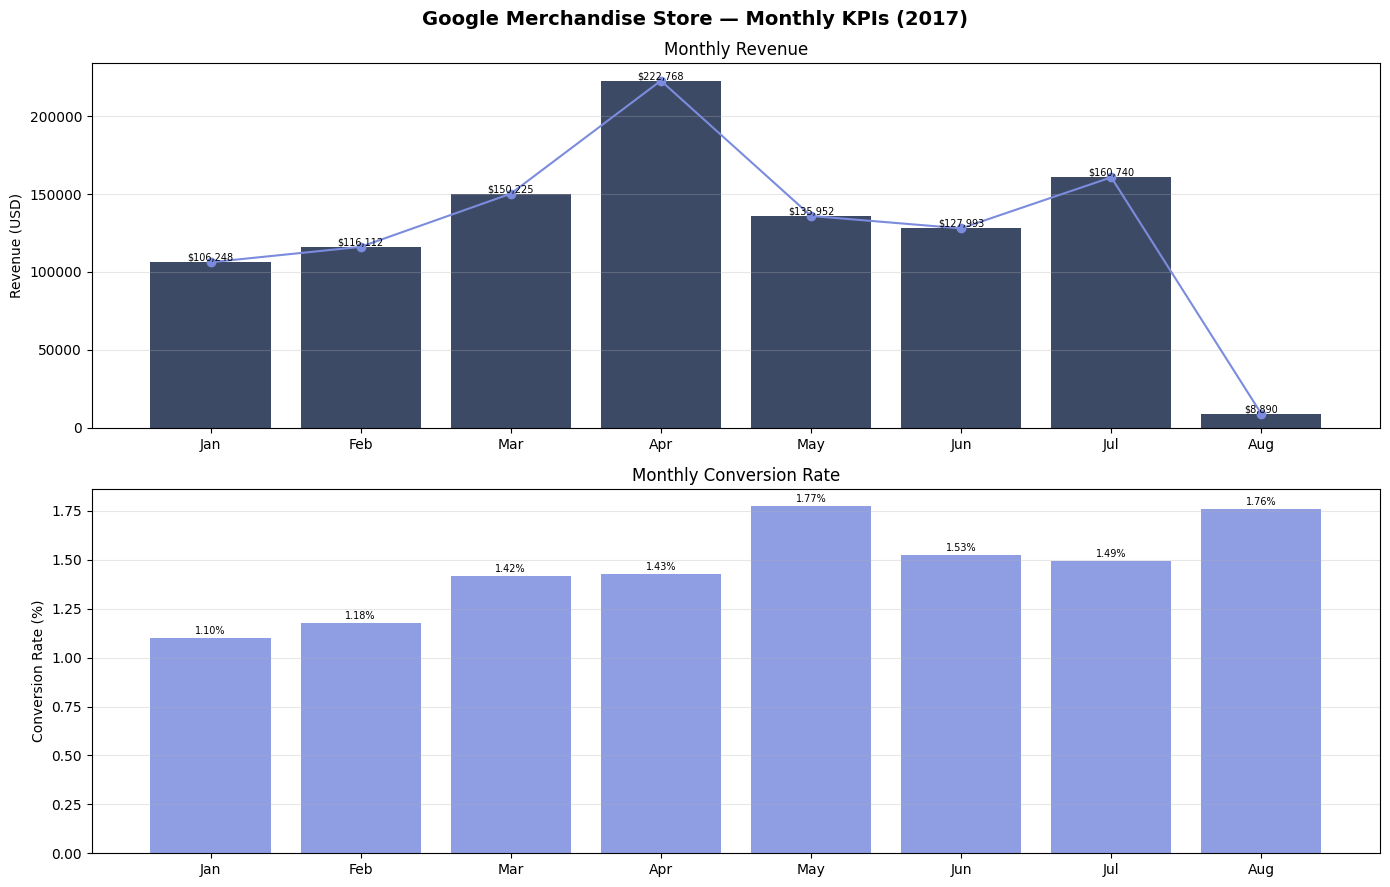

Chart saved.


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Google Merchandise Store — Monthly KPIs (2017)',
             fontsize=14, fontweight='bold')

# Monthly Revenue
axes[0].bar(monthly['month_name'], monthly['total_revenue'],
            color='#1B2A4A', alpha=0.85)
axes[0].plot(monthly['month_name'], monthly['total_revenue'],
             color='#7B8CDE', marker='o', linewidth=1.5)
axes[0].set_ylabel('Revenue (USD)')
axes[0].set_title('Monthly Revenue')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(monthly['total_revenue']):
    axes[0].text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=7)

# Monthly Conversion Rate
axes[1].bar(monthly['month_name'], monthly['conversion_rate'],
            color='#7B8CDE', alpha=0.85)
axes[1].set_ylabel('Conversion Rate (%)')
axes[1].set_title('Monthly Conversion Rate')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(monthly['conversion_rate']):
    axes[1].text(i, v + 0.02, f'{v:.2f}%', ha='center', fontsize=7)

plt.tight_layout()
plt.savefig('../reports/03_monthly_kpis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 5. Weekly Trend Analysis

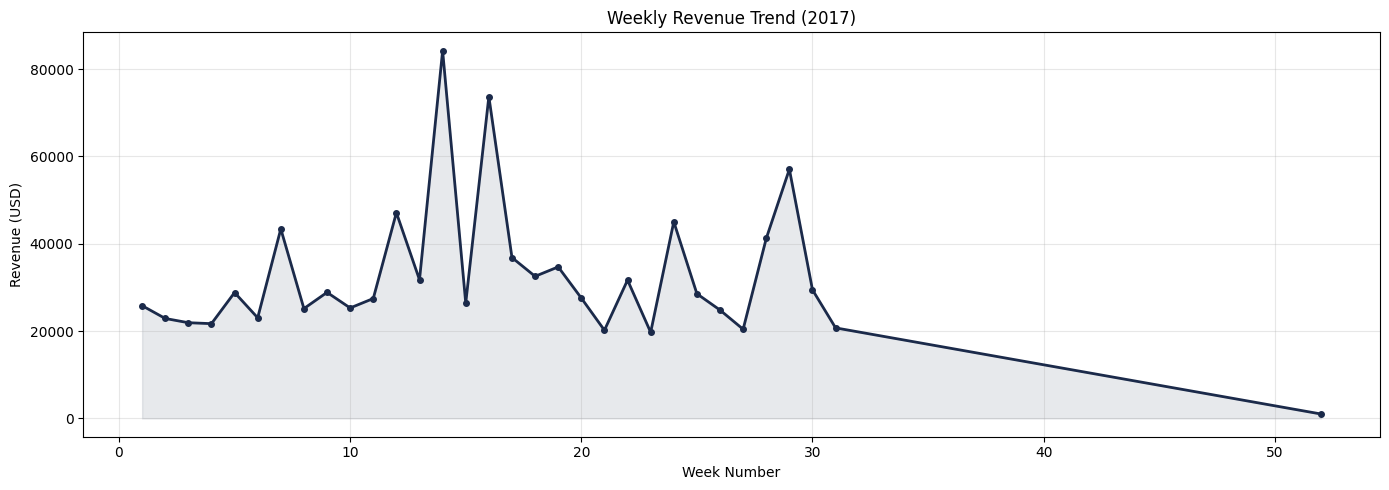

Chart saved.


In [5]:
# Weekly aggregation
weekly = df.groupby('week').agg(
    total_sessions    = ('total_sessions', 'sum'),
    total_revenue     = ('total_revenue', 'sum'),
    total_transactions= ('total_transactions', 'sum')
).reset_index()

weekly['conversion_rate']     = (weekly['total_transactions'] / weekly['total_sessions']) * 100
weekly['revenue_per_session'] = weekly['total_revenue'] / weekly['total_sessions']

plt.figure(figsize=(14, 5))
plt.plot(weekly['week'], weekly['total_revenue'],
         color='#1B2A4A', linewidth=2, marker='o', markersize=4)
plt.fill_between(weekly['week'], weekly['total_revenue'],
                 alpha=0.1, color='#1B2A4A')
plt.title('Weekly Revenue Trend (2017)')
plt.xlabel('Week Number')
plt.ylabel('Revenue (USD)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/03_weekly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 6. Revenue Per Session — Efficiency KPI

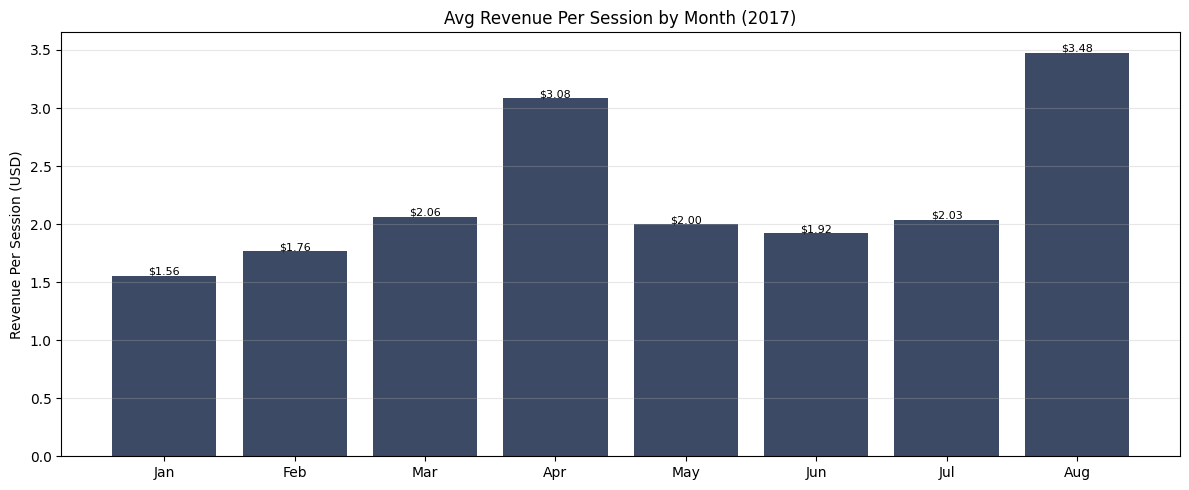

Chart saved.


In [6]:
df['revenue_per_session'] = df['total_revenue'] / df['total_sessions']

# Monthly average revenue per session
rps_monthly = df.groupby('month')['revenue_per_session'].mean().reset_index()
rps_monthly['month_name'] = rps_monthly['month'].map(month_names)

plt.figure(figsize=(12, 5))
plt.bar(rps_monthly['month_name'], rps_monthly['revenue_per_session'],
        color='#1B2A4A', alpha=0.85)
plt.title('Avg Revenue Per Session by Month (2017)')
plt.ylabel('Revenue Per Session (USD)')
plt.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rps_monthly['revenue_per_session']):
    plt.text(i, v + 0.01, f'${v:.2f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/03_revenue_per_session.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## 7. KPI Dashboard Design Rationale

### Tools Selected
- *BigQuery* — data extraction and storage
- *Python (pandas, matplotlib, seaborn)* — cleaning, analysis, and charting
- *Power BI* — interactive KPI dashboard for leadership
- *GTM* — tag management and event tracking configuration
- *HubSpot* — CRM lifecycle and contact management layer

### Metrics Prioritised for Leadership Dashboard
1. *Total Revenue* — headline number, always top of dashboard
2. *Conversion Rate* — most actionable metric for marketing and product teams
3. *Avg Order Value* — indicates upsell and pricing effectiveness
4. *Revenue Per Session* — efficiency metric combining traffic quality and monetisation
5. *Bounce Rate* — traffic quality signal, monitored for tracking integrity
6. *Monthly Revenue Growth %* — trend signal for leadership decisions

### How We Ensure Data Is Trusted by Leadership
- All metrics traced back to verified BigQuery source data
- Outlier days flagged and documented in Notebook 02
- No manually entered figures — all derived programmatically
- Consistent definitions applied across all notebooks
- Audit trail maintained from raw CSV through to final dashboard export

## 8. Export KPI Data for Power BI

In [7]:
# Export monthly KPIs for Power BI
monthly.to_csv('../data/exports/monthly_kpis.csv', index=False)

# Export weekly trends for Power BI
weekly.to_csv('../data/exports/weekly_trends.csv', index=False)

# Export full audited daily data for Power BI
df.to_csv('../data/exports/daily_data_powerbi.csv', index=False)

print("=== EXPORTS COMPLETE ===")
print("monthly_kpis.csv        → data/exports/")
print("weekly_trends.csv       → data/exports/")
print("daily_data_powerbi.csv  → data/exports/")
print(f"\nMonthly KPI rows:  {len(monthly)}")
print(f"Weekly trend rows: {len(weekly)}")
print(f"Daily data rows:   {len(df)}")

=== EXPORTS COMPLETE ===
monthly_kpis.csv        → data/exports/
weekly_trends.csv       → data/exports/
daily_data_powerbi.csv  → data/exports/

Monthly KPI rows:  8
Weekly trend rows: 32
Daily data rows:   213
